## Airbnb Urban Pressure — Rome vs Copenhagen
### Data Visualization Project 2026

This notebook covers the full analytical pipeline for the project
"Who controls Airbnb, and where?" — a comparative analysis of 
short-term rental market concentration and urban pressure in 
Rome and Copenhagen.

**Research question:** To what extent is the Airbnb market 
concentrated among professional hosts, and how does this 
concentration translate into urban pressure across 
neighbourhoods in Rome and Copenhagen?

**Data:** Inside Airbnb listings for Rome (Sep 2025, 37,652 listings) 
and Copenhagen (Sep 2025, 22,994 listings).

**Pipeline:** Data Understanding → Cleaning → Integration → 
Feature Engineering → UPI → EDA → Insight Extraction → 
Analytical Metrics → Export


In [2]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
HERE = os.getcwd()
DATA_DIR = os.path.join(HERE, "data")


ROME_DIR = os.path.join(DATA_DIR, "rome")
PATH_RO = os.path.join(ROME_DIR, "listings_Rome.csv")
PATH_GEO_RO = os.path.join(ROME_DIR, "neighbourhoods_Rome.geojson")


COP_DIR = os.path.join(DATA_DIR, "copenhagen")
PATH_COP = os.path.join(COP_DIR, "listings_Copenhagen.csv")
PATH_GEO_COP = os.path.join(COP_DIR, "neighbourhoods_Copenhagen.geojson")

In [4]:
df_rome = pd.read_csv(PATH_RO)
geo_rome = gpd.read_file(PATH_GEO_RO)

df_cop = pd.read_csv(PATH_COP)
geo_cop = gpd.read_file(PATH_GEO_COP)

In [5]:
df_rome.head()


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2737,https://www.airbnb.com/rooms/2737,20250914152919,2025-09-15,city scrape,"Elif's room in cozy, clean flat.",10 min by bus you can get to Piazza Venezia or...,It used to be an industrial area until late 80...,https://a0.muscache.com/pictures/41225252/e955...,3047,...,5.00,4.40,4.40,NaN,f,6,0,6,0,0.04
1,11834,https://www.airbnb.com/rooms/11834,20250914152919,2025-09-15,city scrape,"Charming Boschetto Studio, Rome",Fantastic apartment in the Monti district. The...,"""Monti"" with its narrow cobblestone alleys, cr...",https://a0.muscache.com/pictures/miso/Hosting-...,44552,...,4.96,4.99,4.81,IT058091C29VJSIZQZ,f,1,1,0,0,1.62
2,12398,https://www.airbnb.com/rooms/12398,20250914152919,2025-09-15,city scrape,Casa Donatello - Home far from Home,Casa Donatello is a newly renovated two-bedroo...,You are at 15 minutes walking distance from hi...,https://a0.muscache.com/pictures/miso/Hosting-...,11756,...,5.00,4.89,4.83,it058091c2kv6epw8f,f,1,1,0,0,0.47
3,19965,https://www.airbnb.com/rooms/19965,20250914152919,2025-09-15,city scrape,S. Peter's Square 5 Min WALK bright and quite ...,AT ONLY 5 MINUTES WALK to S.Peter's Basilica S...,Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.90,4.90,4.54,IT058091C20YD35BX2,t,3,3,0,0,1.07
4,19967,https://www.airbnb.com/rooms/19967,20250914152919,2025-09-15,city scrape,*In front Vatican Museums 2 bedrooms quite bri...,"IN FRONT of the Vatican Museums entrance, at O...",Prati is a famous neighbourhood (rione of Rome...,https://a0.muscache.com/pictures/hosting/Hosti...,75450,...,4.80,4.85,4.28,IT058091C20YD35BX2,t,3,3,0,0,0.32


In [6]:
df_cop.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,23500,https://www.airbnb.com/rooms/23500,20250929042231,2025-09-29,city scrape,Nice room - great area (Vesterbro),Nice and cosy room in the heart of Copenhagen ...,NaN,https://a0.muscache.com/pictures/123766/fa4694...,92053,...,5.00,5.00,4.80,NaN,f,2,1,1,0,0.08
1,29118,https://www.airbnb.com/rooms/29118,20250929042231,2025-09-29,city scrape,Best Location in Cool Istedgade,NaN,NaN,https://a0.muscache.com/pictures/b83c7003-367a...,125230,...,5.00,4.84,4.74,NaN,f,1,1,0,0,0.15
2,31094,https://www.airbnb.com/rooms/31094,20250929042231,2025-09-30,previous scrape,"Beautiful, spacious, central, renovated Penthouse","Welcome to our home, we hope you will enjoy Wo...","What else is nearby?<br />To be honest, We thi...",https://a0.muscache.com/pictures/miso/Hosting-...,129976,...,4.82,4.80,4.53,NaN,f,1,1,0,0,0.10
3,32379,https://www.airbnb.com/rooms/32379,20250929042231,2025-09-30,previous scrape,"155 m2 artist flat on Vesterbro, with 2 bathrooms",You enter a narrow entrance and feel the good ...,"Værnedamsvej area is super hip area, we call i...",https://a0.muscache.com/pictures/miso/Hosting-...,140105,...,4.92,4.89,4.71,NaN,f,2,1,1,0,0.47
4,32841,https://www.airbnb.com/rooms/32841,20250929042231,2025-09-29,city scrape,Cozy flat for Adults/Quiet for kids,Our flat is placed in a Central AND Quiet neig...,NaN,https://a0.muscache.com/pictures/28047599/8efd...,142143,...,5.00,4.50,4.50,NaN,f,1,1,0,0,0.04


In [7]:
print("Rome shape:", df_rome.shape)
print("Copenhagen shape:", df_cop.shape)

Rome shape: (37652, 79)
Copenhagen shape: (22994, 79)


In [8]:
df_rome.columns.tolist()


['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [9]:
df_cop.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [10]:
df_rome.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object

In [11]:
df_cop.dtypes

id                                                int64
listing_url                                         str
scrape_id                                         int64
last_scraped                                        str
source                                              str
                                                 ...   
calculated_host_listings_count                    int64
calculated_host_listings_count_entire_homes       int64
calculated_host_listings_count_private_rooms      int64
calculated_host_listings_count_shared_rooms       int64
reviews_per_month                               float64
Length: 79, dtype: object

In [12]:
missing_rome = df_rome.isnull().sum().sort_values(ascending=False)
missing_cop = df_cop.isnull().sum().sort_values(ascending=False)

print("ROME - Missing values (top 15):")
print(missing_rome.head(15))

print("\nCOPENHAGEN - Missing values (top 15):")
print(missing_cop.head(15))

ROME - Missing values (top 15):
calendar_updated                37652
neighbourhood_group_cleansed    37652
host_neighbourhood              25411
host_about                      20255
neighbourhood                   19931
neighborhood_overview           19931
host_location                    9861
host_response_rate               6791
host_response_time               6791
review_scores_location           5400
review_scores_value              5399
review_scores_accuracy           5399
review_scores_checkin            5399
review_scores_communication      5398
review_scores_cleanliness        5398
dtype: int64

COPENHAGEN - Missing values (top 15):
neighbourhood_group_cleansed    22994
calendar_updated                22994
license                         22994
host_neighbourhood              18061
neighborhood_overview           15009
neighbourhood                   15009
host_about                      13352
beds                             9556
bathrooms                        9555
esti

In [13]:
missing_pct_rome = (df_rome.isnull().mean() * 100).sort_values(ascending=False)
missing_pct_cop = (df_cop.isnull().mean() * 100).sort_values(ascending=False)

missing_pct_rome.head(15)

calendar_updated                100.000000
neighbourhood_group_cleansed    100.000000
host_neighbourhood               67.489111
host_about                       53.795283
neighbourhood                    52.934771
neighborhood_overview            52.934771
host_location                    26.189844
host_response_rate               18.036226
host_response_time               18.036226
review_scores_location           14.341868
review_scores_value              14.339212
review_scores_accuracy           14.339212
review_scores_checkin            14.339212
review_scores_communication      14.336556
review_scores_cleanliness        14.336556
dtype: float64

In [14]:
missing_pct_cop.head(15)

neighbourhood_group_cleansed    100.000000
calendar_updated                100.000000
license                         100.000000
host_neighbourhood               78.546577
neighborhood_overview            65.273550
neighbourhood                    65.273550
host_about                       58.067322
beds                             41.558667
bathrooms                        41.554319
estimated_revenue_l365d          41.541272
price                            41.541272
host_response_time               36.392102
host_response_rate               36.392102
host_acceptance_rate             22.697225
host_location                    16.495608
dtype: float64

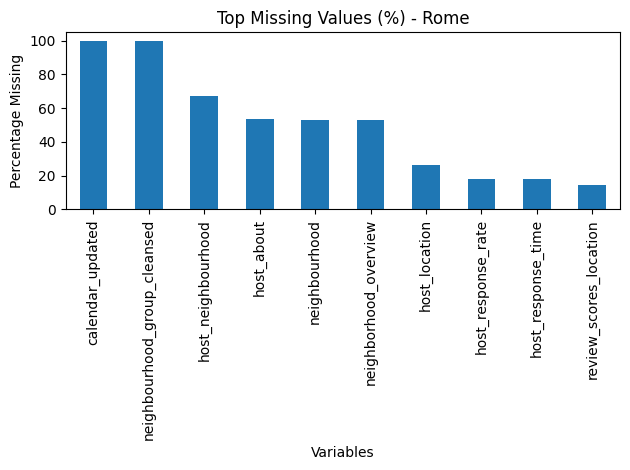

In [61]:
top_missing = missing_pct_rome.head(10)

plt.figure()
top_missing.plot(kind='bar')
plt.title("Top Missing Values (%) - Rome")
plt.xlabel("Variables")
plt.ylabel("Percentage Missing")
plt.xticks(rotation=90)
plt.tight_layout()


<Figure size 640x480 with 0 Axes>

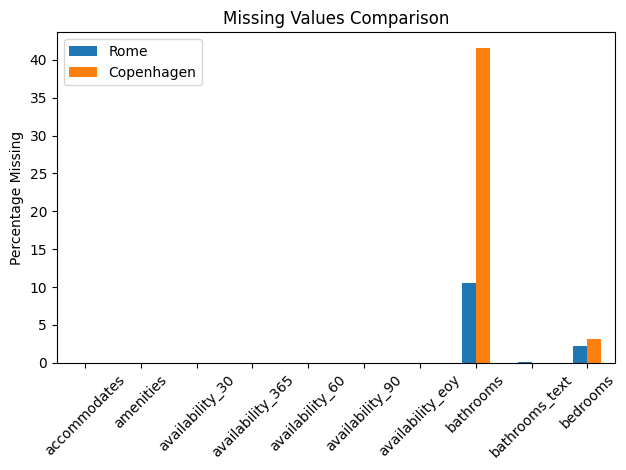

In [16]:
compare_missing = pd.DataFrame({
    "Rome": missing_pct_rome,
    "Copenhagen": missing_pct_cop
}).fillna(0)

top_compare = compare_missing.head(10)

plt.figure()
top_compare.plot(kind='bar')
plt.title("Missing Values Comparison")
plt.ylabel("Percentage Missing")
plt.xticks(rotation=45)
plt.tight_layout()


Text(0, 0.5, 'Frequency')

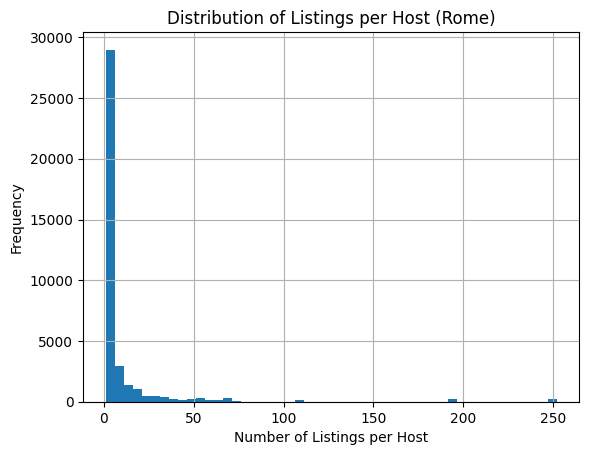

In [17]:
plt.figure()

df_rome["calculated_host_listings_count"].hist(bins=50)

plt.title("Distribution of Listings per Host (Rome)")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency (log scale)')

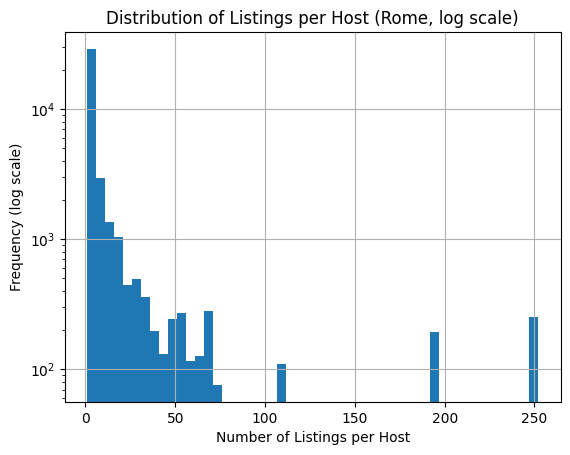

In [18]:
plt.figure()

df_rome["calculated_host_listings_count"].hist(bins=50)

plt.yscale("log")

plt.title("Distribution of Listings per Host (Rome, log scale)")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Frequency (log scale)")

Text(0, 0.5, 'Frequency')

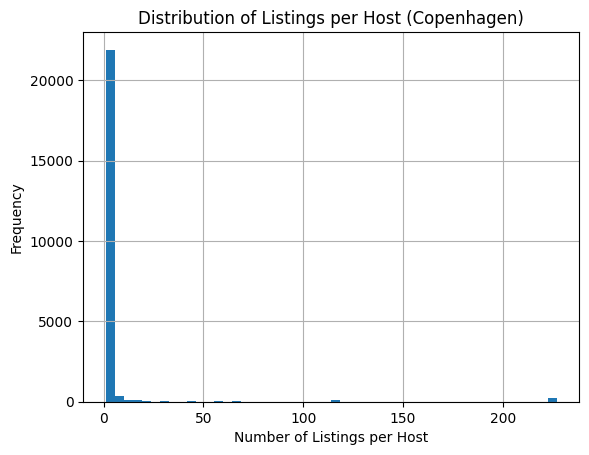

In [19]:
plt.figure()

df_cop["calculated_host_listings_count"].hist(bins=50)

plt.title("Distribution of Listings per Host (Copenhagen)")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency (log scale)')

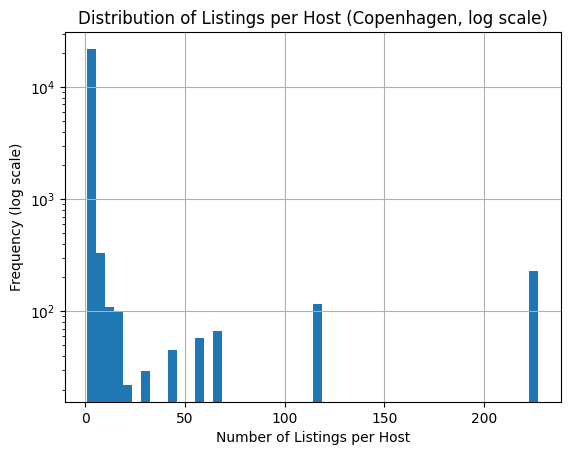

In [20]:
plt.figure()

df_cop["calculated_host_listings_count"].hist(bins=50)

plt.yscale("log")

plt.title("Distribution of Listings per Host (Copenhagen, log scale)")
plt.xlabel("Number of Listings per Host")
plt.ylabel("Frequency (log scale)")

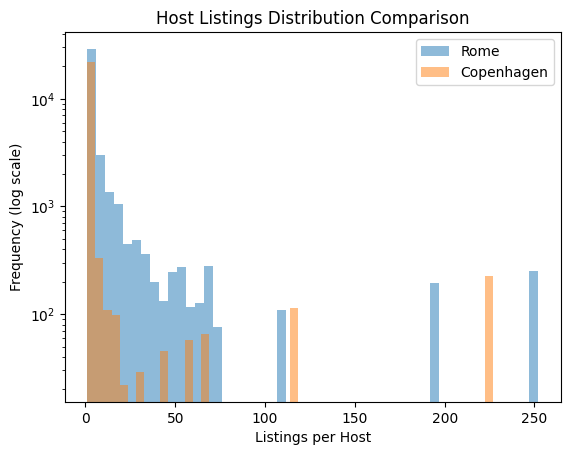

In [21]:
plt.figure()

plt.hist(df_rome["calculated_host_listings_count"], bins=50, alpha=0.5, label="Rome")
plt.hist(df_cop["calculated_host_listings_count"], bins=50, alpha=0.5, label="Copenhagen")

plt.yscale("log")

plt.title("Host Listings Distribution Comparison")
plt.xlabel("Listings per Host")
plt.ylabel("Frequency (log scale)")
plt.legend()

Text(0, 0.5, 'Frequency')

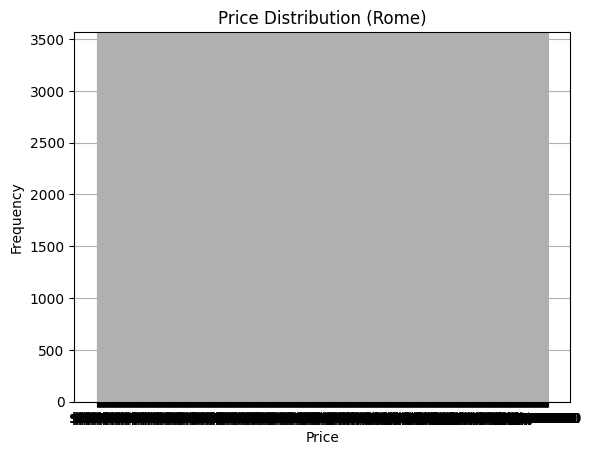

In [22]:
plt.figure()
df_rome["price"].hist(bins=50)

plt.title("Price Distribution (Rome)")
plt.xlabel("Price")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency (log scale)')

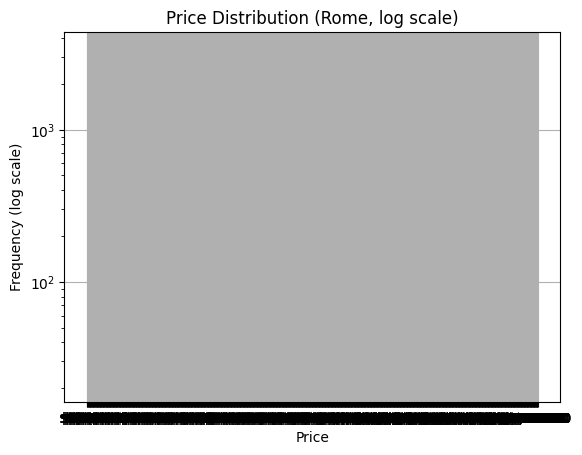

In [23]:
plt.figure()
df_rome["price"].hist(bins=50)

plt.yscale("log")

plt.title("Price Distribution (Rome, log scale)")
plt.xlabel("Price")
plt.ylabel("Frequency (log scale)")

Text(0, 0.5, 'Frequency')

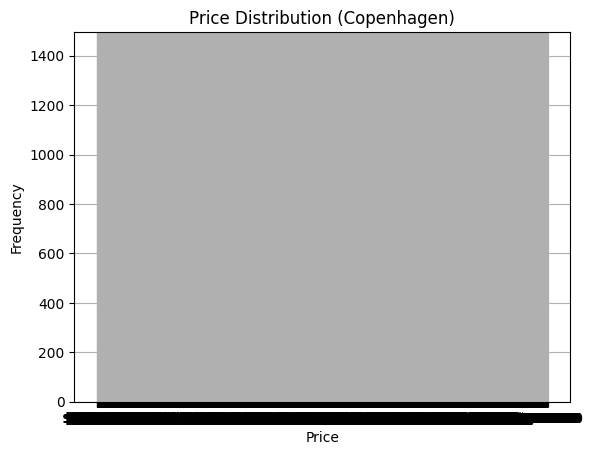

In [24]:
plt.figure()
df_cop["price"].hist(bins=50)

plt.title("Price Distribution (Copenhagen)")
plt.xlabel("Price")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency (log scale)')

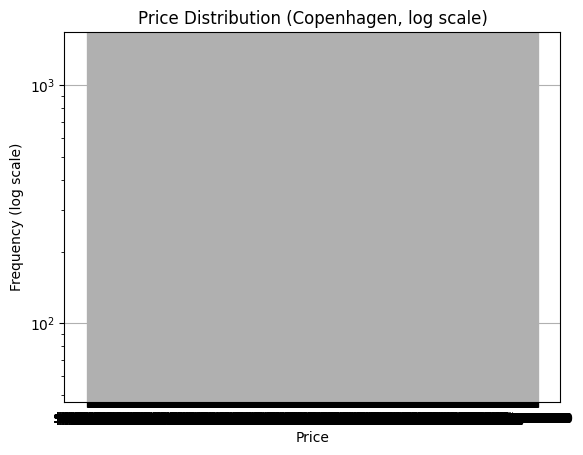

In [25]:
plt.figure()
df_cop["price"].hist(bins=50)

plt.yscale("log")

plt.title("Price Distribution (Copenhagen, log scale)")
plt.xlabel("Price")
plt.ylabel("Frequency (log scale)")

Text(0, 0.5, 'Frequency')

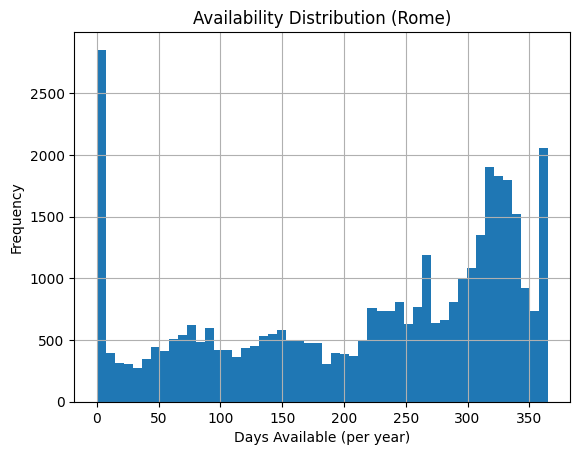

In [26]:
plt.figure()
df_rome["availability_365"].hist(bins=50)

plt.title("Availability Distribution (Rome)")
plt.xlabel("Days Available (per year)")
plt.ylabel("Frequency")

Text(0, 0.5, 'Frequency')

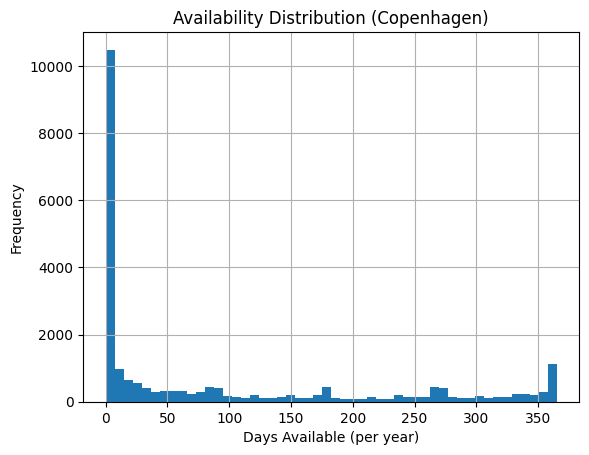

In [27]:
plt.figure()
df_cop["availability_365"].hist(bins=50)

plt.title("Availability Distribution (Copenhagen)")
plt.xlabel("Days Available (per year)")
plt.ylabel("Frequency")

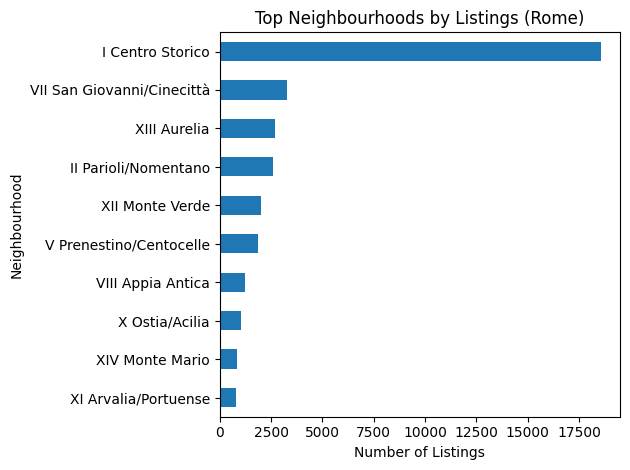

In [28]:
top_neigh = df_rome["neighbourhood_cleansed"].value_counts().head(10)

plt.figure()

top_neigh.sort_values().plot(kind="barh")

plt.title("Top Neighbourhoods by Listings (Rome)")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")

plt.tight_layout()

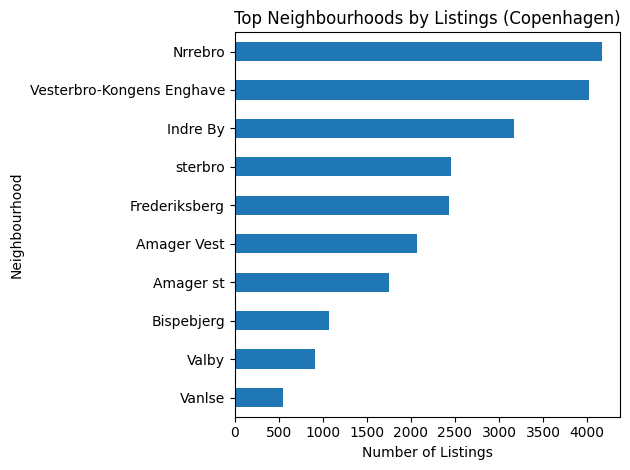

In [29]:
top_neigh = df_cop["neighbourhood_cleansed"].value_counts().head(10)

plt.figure()

top_neigh.sort_values().plot(kind="barh")

plt.title("Top Neighbourhoods by Listings (Copenhagen)")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")

plt.tight_layout()

## Data Cleaning

Now that we have a clear picture of the data, we can start cleaning it.
The steps are:
1. Select only the columns we actually need
2. Convert price to a numeric format
3. Convert Copenhagen prices from DKK to EUR
4. Drop rows where price is missing
5. Remove extreme outliers (above 99th percentile)
6. Add a city identifier
7. Rename columns for consistency

We document how many rows we lose at each step, so we can report 
this honestly in the paper.

In [30]:
KEY_VARS = [
    "host_id",
    "calculated_host_listings_count",
    "room_type",
    "price",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "estimated_revenue_l365d",
    "neighbourhood_cleansed",
    "latitude",
    "longitude"
]

df_rome = df_rome[KEY_VARS].copy()
df_cop  = df_cop[KEY_VARS].copy()

print("Rome:      ", df_rome.shape)
print("Copenhagen:", df_cop.shape)

Rome:       (37652, 12)
Copenhagen: (22994, 12)


### Price cleaning

The price column is stored as a string like "$57.00". 
We strip the dollar sign and convert to float.

In [31]:
for df in [df_rome, df_cop]:
    df["price"] = (
        df["price"]
        .str.replace(r"[\$,]", "", regex=True)
        .astype(float)
    )

print("Rome price dtype:      ", df_rome["price"].dtype)
print("Copenhagen price dtype:", df_cop["price"].dtype)

Rome price dtype:       float64
Copenhagen price dtype: float64


### Currency conversion

Rome prices are in EUR, Copenhagen prices are in DKK.
To make the comparison meaningful, we convert Copenhagen to EUR
using the exchange rate from September 2025: 1 DKK = 0.134 EUR.

This is a simplification — exchange rates fluctuate — but since both 
datasets were scraped in September 2025, it is a reasonable approximation.

In [32]:
DKK_TO_EUR = 0.134  # September 2025 rate

df_cop["price"] = df_cop["price"] * DKK_TO_EUR

print("Copenhagen price after conversion:")
print(df_cop["price"].describe().round(2))

Copenhagen price after conversion:
count    13442.00
mean       193.76
std        261.90
min         18.22
25%        120.60
50%        160.80
75%        222.84
max      15135.97
Name: price, dtype: float64


### Dropping missing prices

Copenhagen has ~41% of listings with no price recorded — these are 
listings that were active in a previous scrape but are no longer available.
We drop them for price-based analysis. We note the row counts before 
and after so we can report this in the paper.

In [33]:
rome_before = len(df_rome)
cop_before  = len(df_cop)

df_rome = df_rome.dropna(subset=["price"])
df_cop  = df_cop.dropna(subset=["price"])

print(f"Rome:      {rome_before} → {len(df_rome)} rows ({rome_before - len(df_rome)} dropped)")
print(f"Copenhagen: {cop_before} → {len(df_cop)} rows ({cop_before - len(df_cop)} dropped)")

Rome:      37652 → 33564 rows (4088 dropped)
Copenhagen: 22994 → 13442 rows (9552 dropped)


### Removing outliers

We remove listings above the 99th percentile of price within each city.
This is more appropriate than a fixed threshold because price distributions 
differ between Rome and Copenhagen — what counts as "extreme" depends 
on the local market.

We do NOT remove listings below a minimum price, because zero-price or 
very low-price listings can reflect legitimate arrangements (e.g. 
rooms listed symbolically) and removing them would require a judgement 
call we cannot justify empirically.

In [34]:
p99_rome = df_rome["price"].quantile(0.99)
p99_cop  = df_cop["price"].quantile(0.99)

print(f"Rome 99th percentile:       €{p99_rome:.2f}")
print(f"Copenhagen 99th percentile: €{p99_cop:.2f}")

rome_before = len(df_rome)
cop_before  = len(df_cop)

df_rome = df_rome[df_rome["price"] <= p99_rome]
df_cop  = df_cop[df_cop["price"]  <= p99_cop]

print(f"\nRome:       {rome_before} → {len(df_rome)} rows ({rome_before - len(df_rome)} dropped)")
print(f"Copenhagen: {cop_before} → {len(df_cop)} rows ({cop_before - len(df_cop)} dropped)")

Rome 99th percentile:       €1005.74
Copenhagen 99th percentile: €658.12

Rome:       33564 → 33228 rows (336 dropped)
Copenhagen: 13442 → 13307 rows (135 dropped)


### Missing values in remaining columns

After price cleaning, we check what is still missing in the columns 
we care about. For `reviews_per_month`, nulls mean the listing has 
no reviews yet — we fill these with 0, which is the correct value.
For `estimated_revenue_l365d`, we keep the nulls for now and only 
use this column where it is available.

In [35]:
df_rome["reviews_per_month"] = df_rome["reviews_per_month"].fillna(0)
df_cop["reviews_per_month"]  = df_cop["reviews_per_month"].fillna(0)

# check what remains
for city, df in [("Rome", df_rome), ("Copenhagen", df_cop)]:
    print(f"\n--- {city} ---")
    print(df.isnull().sum())


--- Rome ---
host_id                           0
calculated_host_listings_count    0
room_type                         0
price                             0
minimum_nights                    0
availability_365                  0
number_of_reviews                 0
reviews_per_month                 0
estimated_revenue_l365d           0
neighbourhood_cleansed            0
latitude                          0
longitude                         0
dtype: int64

--- Copenhagen ---
host_id                           0
calculated_host_listings_count    0
room_type                         0
price                             0
minimum_nights                    0
availability_365                  0
number_of_reviews                 0
reviews_per_month                 0
estimated_revenue_l365d           0
neighbourhood_cleansed            0
latitude                          0
longitude                         0
dtype: int64


### Adding city label and renaming columns

We add a `city` column before merging, and rename 
`neighbourhood_cleansed` to `neighbourhood` for readability.

In [36]:
df_rome["city"] = "Rome"
df_cop["city"]  = "Copenhagen"

df_rome = df_rome.rename(columns={"neighbourhood_cleansed": "neighbourhood"})
df_cop  = df_cop.rename(columns={"neighbourhood_cleansed": "neighbourhood"})

print("Rome columns:      ", df_rome.columns.tolist())
print("Copenhagen columns:", df_cop.columns.tolist())

Rome columns:       ['host_id', 'calculated_host_listings_count', 'room_type', 'price', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'estimated_revenue_l365d', 'neighbourhood', 'latitude', 'longitude', 'city']
Copenhagen columns: ['host_id', 'calculated_host_listings_count', 'room_type', 'price', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'estimated_revenue_l365d', 'neighbourhood', 'latitude', 'longitude', 'city']


### Final check before integration

A quick summary of the two cleaned datasets before merging them.

In [37]:
for city, df in [("Rome", df_rome), ("Copenhagen", df_cop)]:
    print(f"\n=== {city} ===")
    print(f"Rows: {len(df)}")
    print(df[["price", "availability_365", 
              "calculated_host_listings_count"]].describe().round(2))


=== Rome ===
Rows: 33228
          price  availability_365  calculated_host_listings_count
count  33228.00          33228.00                        33228.00
mean     165.78            230.26                            9.54
std      123.87            105.61                           27.63
min        8.00              0.00                            1.00
25%       93.00            145.00                            1.00
50%      132.00            260.00                            2.00
75%      192.00            321.00                            6.00
max     1005.00            365.00                          252.00

=== Copenhagen ===
Rows: 13307
          price  availability_365  calculated_host_listings_count
count  13307.00          13307.00                        13307.00
mean     181.80            150.78                            6.88
std       92.26            126.56                           31.07
min       18.22              0.00                            1.00
25%      120.60   

In [38]:
print("=== CLEANING COMPLETE ===")
print(f"Rome final shape: {df_rome.shape}")
print(f"Copenhagen final shape: {df_cop.shape}")

=== CLEANING COMPLETE ===
Rome final shape: (33228, 13)
Copenhagen final shape: (13307, 13)


## Data Integration

The two datasets have been cleaned separately and now share 
the same schema. Before merging, we verify that the columns 
match exactly, then concatenate into a single dataframe.

We keep the `city` column as the identifier for all 
downstream analysis and visualizations.

In [39]:
# verify columns match before merging
assert list(df_rome.columns) == list(df_cop.columns), \
    "Column mismatch between Rome and Copenhagen!"

print("Columns match ✓")
print(df_rome.columns.tolist())

Columns match ✓
['host_id', 'calculated_host_listings_count', 'room_type', 'price', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'estimated_revenue_l365d', 'neighbourhood', 'latitude', 'longitude', 'city']


In [40]:
df = pd.concat([df_rome, df_cop], ignore_index=True)

print(f"Rome:        {len(df_rome):,} rows")
print(f"Copenhagen:  {len(df_cop):,} rows")
print(f"Combined:    {len(df):,} rows")
print(f"\nShape: {df.shape}")
print(f"Cities: {df['city'].value_counts().to_dict()}")

Rome:        33,228 rows
Copenhagen:  13,307 rows
Combined:    46,535 rows

Shape: (46535, 13)
Cities: {'Rome': 33228, 'Copenhagen': 13307}


In [41]:
# make sure there are no unexpected nulls after merge
print(df.isnull().sum())

host_id                           0
calculated_host_listings_count    0
room_type                         0
price                             0
minimum_nights                    0
availability_365                  0
number_of_reviews                 0
reviews_per_month                 0
estimated_revenue_l365d           0
neighbourhood                     0
latitude                          0
longitude                         0
city                              0
dtype: int64


## Feature Engineering

This section derives the analytical variables we need for both 
the host concentration analysis and the Urban Pressure Index.

We work on the combined dataframe `df` and add new columns 
without modifying the cleaned data.

### Host listings count

`calculated_host_listings_count` is provided by Inside Airbnb, but it 
reflects a host's total listings globally. We compute our own count 
from the data we have — listings per host within each city — and check 
whether the two measures differ significantly.

In [42]:
# compute listings per host per city from our data
host_counts = (
    df.groupby(["city", "host_id"])["host_id"]
    .count()
    .rename("host_listings_local")
    .reset_index()
)

# merge back into main dataframe
df = df.merge(host_counts, on=["city", "host_id"], how="left")

# compare with Inside Airbnb's pre-computed column
df["count_diff"] = df["calculated_host_listings_count"] - df["host_listings_local"]

print("Difference between calculated and local count:")
print(df["count_diff"].describe().round(2))
print(f"\nListings where counts differ: {(df['count_diff'] != 0).sum():,}")
print(f"Total listings: {len(df):,}")

Difference between calculated and local count:
count    46535.00
mean         0.64
std          2.71
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         31.00
Name: count_diff, dtype: float64

Listings where counts differ: 7,381
Total listings: 46,535


We expect differences — `calculated_host_listings_count` includes 
listings outside Rome and Copenhagen, while `host_listings_local` 
only counts listings in our dataset. We use `host_listings_local` 
for all concentration analysis, as it reflects activity within 
the cities we are studying.

### Host classification

We classify hosts into three categories based on the number of 
listings they manage within each city:

- **Casual**: 1 listing — occasional hosts, closer to the original 
  sharing economy model
- **Semi-professional**: 2–4 listings — small multi-listing operators
- **Professional**: 5 or more listings — commercial operators 
  with significant market presence

This classification follows Wachsmuth & Weisler (2018) and is 
consistent with the approach used by Inside Airbnb.

In [43]:
def classify_host(n):
    if n == 1:
        return "Casual"
    elif n <= 4:
        return "Semi-professional"
    else:
        return "Professional"

df["host_category"] = df["host_listings_local"].apply(classify_host)

# quick check
print(df.groupby(["city", "host_category"])["host_id"].count())

city        host_category    
Copenhagen  Casual               11350
            Professional          1042
            Semi-professional      915
Rome        Casual               13810
            Professional          9766
            Semi-professional     9652
Name: host_id, dtype: int64


### Neighbourhood-level aggregates

We aggregate listing-level data to the neighbourhood level to 
capture the spatial dimension of Airbnb activity.

For each neighbourhood we compute:
- `listing_count` — total number of listings
- `avg_price` — average price per night (EUR)
- `avg_availability` — average days available per year
- `professional_share` — share of listings managed by professional hosts

These four metrics are also the inputs for the Urban Pressure Index,
which we construct in the next section.

In [44]:
neighbourhood_stats = (
    df.groupby(["city", "neighbourhood"])
    .agg(
        listing_count    = ("host_id",           "count"),
        avg_price        = ("price",              "mean"),
        avg_availability = ("availability_365",   "mean"),
        professional_share = ("host_category",
                              lambda x: (x == "Professional").mean() * 100)
    )
    .round(2)
    .reset_index()
)

print(neighbourhood_stats.shape)
print(neighbourhood_stats.head(10))

(26, 6)
         city              neighbourhood  listing_count  avg_price  \
0  Copenhagen                Amager Vest           1225     182.27   
1  Copenhagen                  Amager st           1020     167.89   
2  Copenhagen                 Bispebjerg            595     135.06   
3  Copenhagen               Brnshj-Husum            232     144.65   
4  Copenhagen              Frederiksberg           1402     183.69   
5  Copenhagen                   Indre By           2074     241.59   
6  Copenhagen                    Nrrebro           2220     159.37   
7  Copenhagen                      Valby            475     144.43   
8  Copenhagen                     Vanlse            331     147.79   
9  Copenhagen  Vesterbro-Kongens Enghave           2286     179.79   

   avg_availability  professional_share  
0            146.66                8.00  
1            143.49                8.14  
2            158.70                8.74  
3            177.52                3.88  
4          

A quick sanity check: the neighbourhoods with the highest listing 
counts should match what we expect from each city.

In [45]:
for city in ["Rome", "Copenhagen"]:
    print(f"\n--- {city} — top 5 neighbourhoods by listing count ---")
    top = (
        neighbourhood_stats[neighbourhood_stats["city"] == city]
        .sort_values("listing_count", ascending=False)
        .head(5)
    )
    print(top[["neighbourhood", "listing_count", 
               "avg_price", "professional_share"]].to_string(index=False))


--- Rome — top 5 neighbourhoods by listing count ---
             neighbourhood  listing_count  avg_price  professional_share
          I Centro Storico          16310     209.68               38.84
VII San Giovanni/Cinecittà           2944     125.63               20.45
              XIII Aurelia           2435     149.33               24.39
      II Parioli/Nomentano           2253     144.07               27.61
           XII Monte Verde           1740     127.47               19.20

--- Copenhagen — top 5 neighbourhoods by listing count ---
            neighbourhood  listing_count  avg_price  professional_share
Vesterbro-Kongens Enghave           2286     179.79                5.60
                  Nrrebro           2220     159.37                3.83
                 Indre By           2074     241.59               20.59
                  sterbro           1447     186.51                5.60
            Frederiksberg           1402     183.69                4.07


## Urban Pressure Index (UPI)

The Urban Pressure Index is a composite metric that captures the 
intensity of Airbnb activity at the neighbourhood level. It combines 
multiple dimensions of short-term rental pressure into a single, 
interpretable score that allows direct comparison across neighbourhoods 
and cities.

### Component selection

The UPI is built from two variables:

- **Listing density** (`listing_count`): the number of Airbnb listings 
  per neighbourhood, capturing the raw volume of short-term rental 
  activity and its spatial concentration.

- **Availability intensity** (`avg_availability`): the average number 
  of days per year a listing is available, serving as a proxy for 
  how actively listings are used for short-term rental purposes.

We initially considered including average price as a third component. 
However, Copenhagen has approximately 41% of listings with no price 
recorded — these correspond to listings that appeared in previous 
scrapes but are no longer active. While we dropped these rows from 
the main dataset for listing-level analysis, the remaining prices 
may not be representative of all neighbourhoods in Copenhagen. 
Including price in the UPI would risk introducing a systematic bias 
in the Copenhagen component, making the cross-city comparison less 
reliable.

We therefore exclude price from the UPI and use it separately as 
a descriptive variable. The UPI measures pressure in terms of 
density and intensity of use — two dimensions that are complete 
and comparable across both cities.

### Weighting

We assign equal weights to the two components (50% each). 
This is the most conservative and defensible choice in the 
absence of empirical evidence that one dimension contributes 
more to urban pressure than the other. Equal weighting also 
maximises transparency and reproducibility.

### Normalisation

Before combining, each component is normalised to a 0–1 scale 
using min-max normalisation. This ensures that the two variables 
— which are measured in different units (count vs days) — 
contribute equally to the final index regardless of their 
original scale.

In [46]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# normalise within each city separately
# this way we compare relative pressure within each city,
# not absolute values across cities

for city in ["Rome", "Copenhagen"]:
    mask = neighbourhood_stats["city"] == city
    
    neighbourhood_stats.loc[mask, "listing_count_norm"] = scaler.fit_transform(
        neighbourhood_stats.loc[mask, ["listing_count"]]
    )
    neighbourhood_stats.loc[mask, "availability_norm"] = scaler.fit_transform(
        neighbourhood_stats.loc[mask, ["avg_availability"]]
    )

print("Normalisation complete.")
print(neighbourhood_stats[["city", "neighbourhood", 
                            "listing_count_norm", 
                            "availability_norm"]].head(10))

Normalisation complete.
         city              neighbourhood  listing_count_norm  \
0  Copenhagen                Amager Vest            0.483447   
1  Copenhagen                  Amager st            0.383642   
2  Copenhagen                 Bispebjerg            0.176728   
3  Copenhagen               Brnshj-Husum            0.000000   
4  Copenhagen              Frederiksberg            0.569620   
5  Copenhagen                   Indre By            0.896787   
6  Copenhagen                    Nrrebro            0.967868   
7  Copenhagen                      Valby            0.118306   
8  Copenhagen                     Vanlse            0.048199   
9  Copenhagen  Vesterbro-Kongens Enghave            1.000000   

   availability_norm  
0           0.241023  
1           0.163060  
2           0.537137  
3           1.000000  
4           0.329562  
5           0.971963  
6           0.000000  
7           0.364978  
8           0.464584  
9           0.175603  


### Why normalise within each city?

We normalise listing count and availability separately for Rome 
and Copenhagen, rather than across both cities together.

If we normalised globally, Rome's Centro Storico — with over 16,000 
listings — would score 1.0 on density and compress all Copenhagen 
neighbourhoods toward 0, making the within-city comparison for 
Copenhagen essentially meaningless.

Normalising within each city means the UPI reflects relative pressure 
within each urban context. A score of 1.0 means "the most pressured 
neighbourhood in that city", not "the most pressured neighbourhood 
overall". This is appropriate for our research question, which asks 
how pressure is distributed within each city and how the two 
distributions compare structurally.

In [47]:
# equal weights: 50% density, 50% availability
neighbourhood_stats["UPI"] = (
    0.5 * neighbourhood_stats["listing_count_norm"] +
    0.5 * neighbourhood_stats["availability_norm"]
).round(4)

print("UPI range:")
print(neighbourhood_stats.groupby("city")["UPI"].describe().round(3))

UPI range:
            count   mean    std    min    25%    50%    75%    max
city                                                              
Copenhagen   11.0  0.442  0.197  0.242  0.315  0.412  0.492  0.934
Rome         15.0  0.270  0.180  0.040  0.169  0.245  0.363  0.666


### Top neighbourhoods by UPI

In [48]:
for city in ["Rome", "Copenhagen"]:
    print(f"\n--- {city} — top 5 by UPI ---")
    top = (
        neighbourhood_stats[neighbourhood_stats["city"] == city]
        .sort_values("UPI", ascending=False)
        .head(5)
    )
    print(top[["neighbourhood", "listing_count", 
               "avg_availability", "UPI"]].to_string(index=False))


--- Rome — top 5 by UPI ---
      neighbourhood  listing_count  avg_availability    UPI
   I Centro Storico          16310            230.07 0.6661
 XV Cassia/Flaminia            524            249.14 0.5066
VI Roma delle Torri            312            246.72 0.4576
             IX Eur            383            243.08 0.3961
    XIV Monte Mario            769            238.60 0.3298

--- Copenhagen — top 5 by UPI ---
            neighbourhood  listing_count  avg_availability    UPI
                 Indre By           2074            176.38 0.9344
Vesterbro-Kongens Enghave           2286            144.00 0.5878
             Brnshj-Husum            232            177.52 0.5000
                  Nrrebro           2220            136.86 0.4839
            Frederiksberg           1402            150.26 0.4496


## Exploratory Analysis

With the cleaned and integrated dataset, we now explore the key 
distributions and patterns that motivate our visual system.

The goal here is not to produce final visualizations — those go 
in Tableau. The goal is to understand the data well enough to 
make informed design decisions and to identify anything unexpected 
before moving to the visualization phase.

### Price distribution by city

We compare the distribution of listing prices across the two cities.
Prices are already converted to EUR, so the comparison is direct.

Rome: median €132, mean €166, max €1005
Copenhagen: median €161, mean €182, max €656


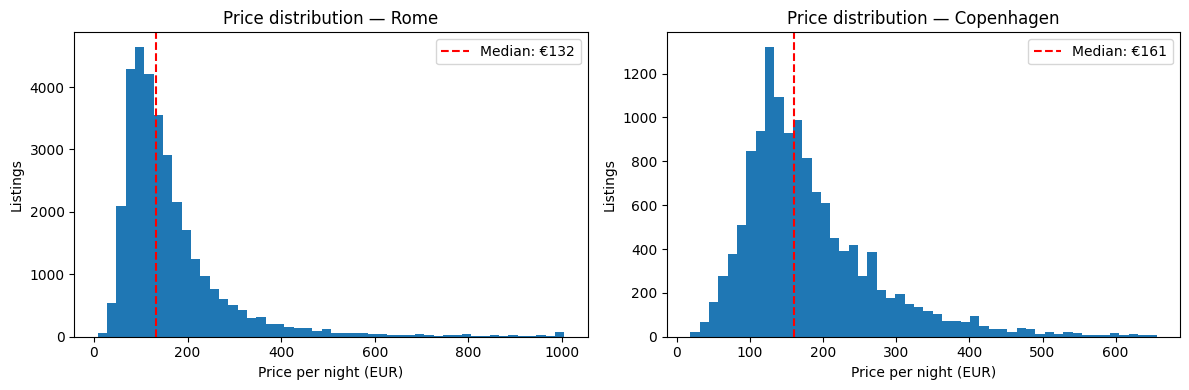

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, city in zip(axes, ["Rome", "Copenhagen"]):
    subset = df[df["city"] == city]["price"]
    ax.hist(subset, bins=50, edgecolor="none")
    ax.set_title(f"Price distribution — {city}")
    ax.set_xlabel("Price per night (EUR)")
    ax.set_ylabel("Listings")
    ax.axvline(subset.median(), color="red", linestyle="--", 
               label=f"Median: €{subset.median():.0f}")
    ax.legend()

plt.tight_layout()

for city in ["Rome", "Copenhagen"]:
    s = df[df["city"] == city]["price"]
    print(f"{city}: median €{s.median():.0f}, mean €{s.mean():.0f}, "
          f"max €{s.max():.0f}")

### Listings per host distribution

This is the core distribution for the concentration analysis.
We expect a strongly right-skewed distribution — most hosts 
have one listing, a few have many.

We use a log scale on the y-axis to make the tail visible.

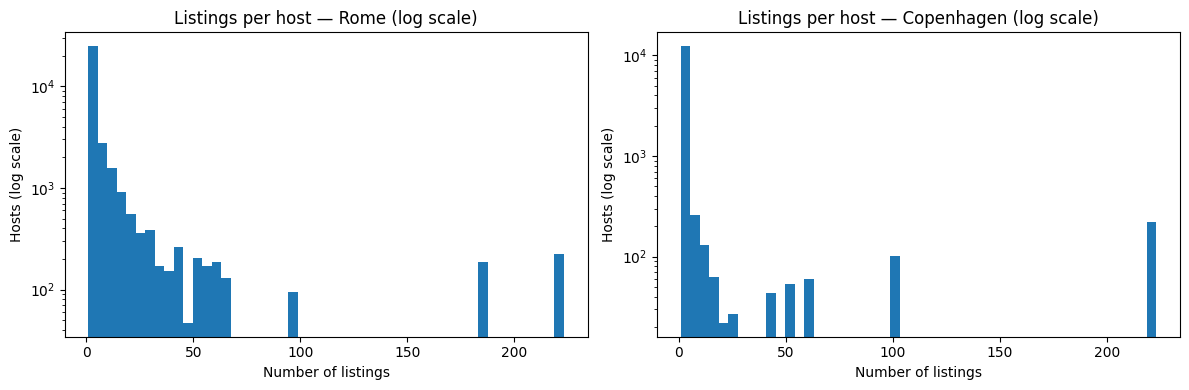

Rome: 41.6% single-listing hosts, max 223 listings
Copenhagen: 85.3% single-listing hosts, max 223 listings


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, city in zip(axes, ["Rome", "Copenhagen"]):
    subset = df[df["city"] == city]["host_listings_local"]
    ax.hist(subset, bins=50, edgecolor="none")
    ax.set_yscale("log")
    ax.set_title(f"Listings per host — {city} (log scale)")
    ax.set_xlabel("Number of listings")
    ax.set_ylabel("Hosts (log scale)")

plt.tight_layout()
plt.show()

for city in ["Rome", "Copenhagen"]:
    s = df[df["city"] == city]["host_listings_local"]
    print(f"{city}: {(s == 1).mean()*100:.1f}% single-listing hosts, "
          f"max {s.max()} listings")

### Host category breakdown

How are listings distributed across host categories in each city?
We look at both the number of hosts and the share of listings 
they control — these two views tell very different stories.

In [51]:
# share of LISTINGS controlled by each category
listing_share = (
    df.groupby(["city", "host_category"])
    .size()
    .reset_index(name="listing_count")
)

listing_share["share"] = (
    listing_share.groupby("city")["listing_count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(1)
)

print(listing_share.sort_values(["city", "host_category"]))

         city      host_category  listing_count  share
0  Copenhagen             Casual          11350   85.3
1  Copenhagen       Professional           1042    7.8
2  Copenhagen  Semi-professional            915    6.9
3        Rome             Casual          13810   41.6
4        Rome       Professional           9766   29.4
5        Rome  Semi-professional           9652   29.0


### Availability distribution

`availability_365` ranges from 0 (never available) to 365 
(always available). A bimodal distribution would suggest two 
distinct behaviours — occasional hosts and commercial operators.

Rome: median 260 days, 67.9% available more than 6 months
Copenhagen: median 115 days, 38.1% available more than 6 months


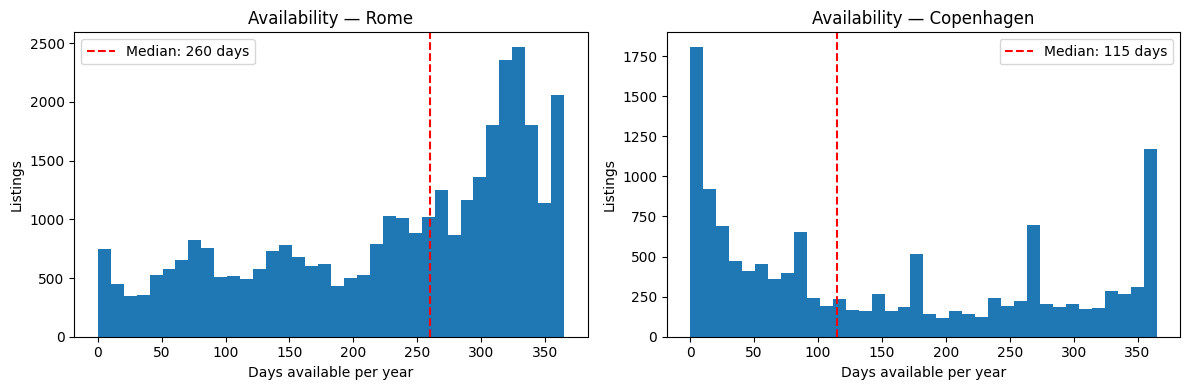

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, city in zip(axes, ["Rome", "Copenhagen"]):
    subset = df[df["city"] == city]["availability_365"]
    ax.hist(subset, bins=36, edgecolor="none")
    ax.set_title(f"Availability — {city}")
    ax.set_xlabel("Days available per year")
    ax.set_ylabel("Listings")
    ax.axvline(subset.median(), color="red", linestyle="--",
               label=f"Median: {subset.median():.0f} days")
    ax.legend()

plt.tight_layout()

for city in ["Rome", "Copenhagen"]:
    s = df[df["city"] == city]["availability_365"]
    print(f"{city}: median {s.median():.0f} days, "
          f"{(s > 180).mean()*100:.1f}% available more than 6 months")

### Room type breakdown

The type of listing (entire home, private room, shared room) 
is a strong indicator of commercialisation. Entire homes 
rented year-round are much more likely to represent housing 
removed from the residential market.

In [53]:
room_share = (
    df.groupby(["city", "room_type"])
    .size()
    .reset_index(name="count")
)

room_share["share"] = (
    room_share.groupby("city")["count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(1)
)

print(room_share.sort_values(["city", "room_type"]).to_string(index=False))

      city       room_type  count  share
Copenhagen Entire home/apt  12168   91.4
Copenhagen      Hotel room      3    0.0
Copenhagen    Private room   1119    8.4
Copenhagen     Shared room     17    0.1
      Rome Entire home/apt  25739   77.5
      Rome      Hotel room    204    0.6
      Rome    Private room   7209   21.7
      Rome     Shared room     76    0.2


## Insight Extraction

Before moving to formal metrics, we summarise the key patterns 
emerging from the exploratory analysis. These observations guide 
both the design of the visual system and the interpretation of results.

**I1 — Market professionalisation is much higher in Rome.**
In Rome, only 41.6% of listings belong to casual single-listing hosts, 
while 29.4% are controlled by professional hosts (5+ listings). 
In Copenhagen, 85.3% of listings are from casual hosts and only 7.8% 
from professionals. This suggests a fundamentally different market 
structure: Rome has moved well beyond the sharing economy model, 
while Copenhagen remains predominantly peer-to-peer.

**I2 — Rome listings are available almost year-round.**
The median availability in Rome is 260 days per year, with 67.9% 
of listings available more than 6 months. In Copenhagen the median 
is 115 days, with only 38.1% exceeding 6 months. Rome's availability 
distribution is nearly flat with a spike near 365 days — a pattern 
consistent with commercial operation rather than occasional hosting.

**I3 — Copenhagen prices are higher despite lower concentration.**
The median price in Copenhagen (€161) exceeds Rome (€132), which is 
counterintuitive given Rome's higher professionalisation. This may 
reflect constrained supply in Copenhagen — fewer active listings 
at any given time — pushing prices upward despite lower commercial 
intensity.

**I4 — Spatial concentration is extreme in Rome.**
Rome's I Centro Storico accounts for 16,310 listings — more than 
the entire Copenhagen dataset combined relative to city size — 
with a professional share of 38.84%. No single Copenhagen neighbourhood 
shows comparable dominance, with the top neighbourhood (Indre By) 
having 2,074 listings and a professional share of 20.59%.

**I5 — The UPI confirms asymmetric pressure.**
Despite Copenhagen having a higher mean UPI score due to 
within-city normalisation, the absolute intensity of Airbnb 
activity in Rome's centre is structurally different in nature: 
driven by high listing density and professional concentration, 
while Copenhagen's pressure is driven by high availability 
of a smaller number of listings.

## Analytical Metrics

We now compute formal measures of market concentration to 
complement the exploratory observations above.

The two main tools are:
- **Lorenz curve**: visualises how unequally listings are 
  distributed across hosts
- **Gini coefficient**: a single number summarising the 
  inequality shown by the Lorenz curve (0 = perfect equality, 
  1 = maximum concentration)

We also look at top host dominance — what share of the market 
is controlled by the top 1% and top 10% of hosts.

### Lorenz curve

The Lorenz curve plots the cumulative share of hosts (x-axis) 
against the cumulative share of listings they control (y-axis). 
A perfectly equal market would follow the diagonal — every 10% 
of hosts controls 10% of listings. The further the curve bows 
below the diagonal, the more concentrated the market.

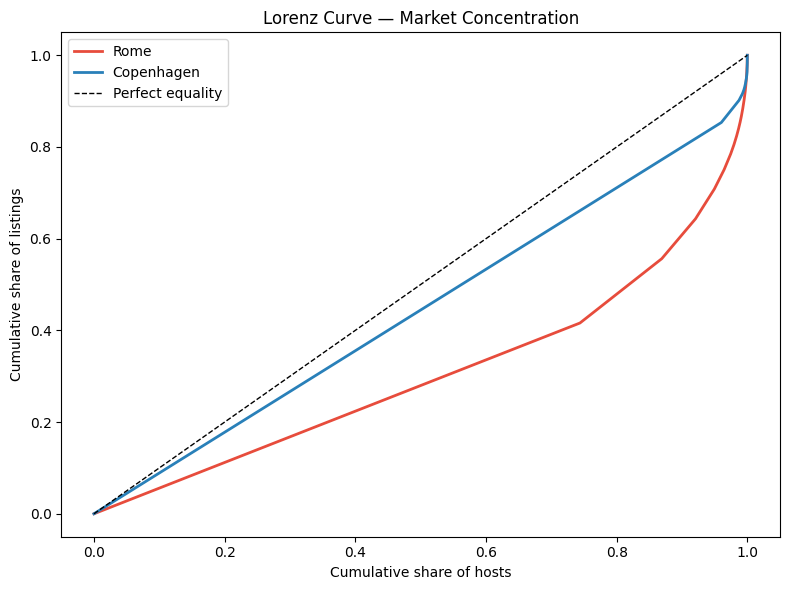

In [54]:
import numpy as np

def lorenz_curve(values):
    """Returns (x, y) points for the Lorenz curve."""
    sorted_vals = np.sort(values)
    cumulative = np.cumsum(sorted_vals)
    cumulative = cumulative / cumulative[-1]
    x = np.linspace(0, 1, len(cumulative))
    return x, cumulative

fig, ax = plt.subplots(figsize=(8, 6))

# one Lorenz curve per city
for city, color in [("Rome", "#e74c3c"), ("Copenhagen", "#2980b9")]:
    host_data = (
        df[df["city"] == city]
        .groupby("host_id")["host_listings_local"]
        .first()
        .values
    )
    x, y = lorenz_curve(host_data)
    ax.plot(x, y, label=city, color=color, linewidth=2)

# equality line
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect equality")

ax.set_xlabel("Cumulative share of hosts")
ax.set_ylabel("Cumulative share of listings")
ax.set_title("Lorenz Curve — Market Concentration")
ax.legend()
plt.tight_layout()


In [55]:
def gini(values):
    """Compute Gini coefficient."""
    sorted_vals = np.sort(values)
    n = len(sorted_vals)
    cumulative = np.cumsum(sorted_vals)
    return (2 * np.sum((np.arange(1, n+1) * sorted_vals)) 
            / (n * cumulative[-1])) - (n + 1) / n

for city in ["Rome", "Copenhagen"]:
    host_data = (
        df[df["city"] == city]
        .groupby("host_id")["host_listings_local"]
        .first()
        .values
    )
    g = gini(host_data)
    print(f"{city} Gini coefficient: {g:.4f}")

Rome Gini coefficient: 0.3873
Copenhagen Gini coefficient: 0.1098


### Top host dominance

We look at what share of total listings is controlled by the 
top 1% and top 10% of hosts by listing count. This is a 
direct measure of market power concentration.

In [56]:
for city in ["Rome", "Copenhagen"]:
    host_data = (
        df[df["city"] == city]
        .groupby("host_id")["host_listings_local"]
        .first()
        .sort_values(ascending=False)
    )
    
    total   = host_data.sum()
    top_1p  = host_data.iloc[:max(1, int(len(host_data) * 0.01))].sum()
    top_10p = host_data.iloc[:max(1, int(len(host_data) * 0.10))].sum()
    
    print(f"\n{city}")
    print(f"  Total hosts:          {len(host_data):,}")
    print(f"  Top 1% controls:      {top_1p/total*100:.1f}% of listings")
    print(f"  Top 10% controls:     {top_10p/total*100:.1f}% of listings")


Rome
  Total hosts:          18,576
  Top 1% controls:      13.9% of listings
  Top 10% controls:     39.2% of listings

Copenhagen
  Total hosts:          11,823
  Top 1% controls:      9.1% of listings
  Top 10% controls:     20.0% of listings


### Market share by host category

Finally, we summarise the share of listings and the share of 
hosts for each category in both cities. These two numbers 
together reveal the asymmetry: a small share of hosts controls 
a disproportionate share of listings.

In [57]:
summary = (
    df.groupby(["city", "host_category"])
    .agg(
        n_listings = ("host_id", "count"),
        n_hosts    = ("host_id", "nunique")
    )
    .reset_index()
)

for city in ["Rome", "Copenhagen"]:
    sub = summary[summary["city"] == city].copy()
    sub["listing_share"] = (sub["n_listings"] / sub["n_listings"].sum() * 100).round(1)
    sub["host_share"]    = (sub["n_hosts"]    / sub["n_hosts"].sum()    * 100).round(1)
    print(f"\n--- {city} ---")
    print(sub[["host_category", "n_hosts", "host_share", 
               "n_listings", "listing_share"]].to_string(index=False))


--- Rome ---
    host_category  n_hosts  host_share  n_listings  listing_share
           Casual    13810        74.3       13810           41.6
     Professional      952         5.1        9766           29.4
Semi-professional     3814        20.5        9652           29.0

--- Copenhagen ---
    host_category  n_hosts  host_share  n_listings  listing_share
           Casual    11350        96.0       11350           85.3
     Professional       70         0.6        1042            7.8
Semi-professional      403         3.4         915            6.9


### Saving the neighbourhood stats

We export `neighbourhood_stats` as a CSV for use in Tableau.
This is the main dataset for all spatial visualizations.

In [58]:
# fix encoding issues in neighbourhood names
name_fixes = {
    "Nrrebro":      "Nørrebro",
    "sterbro":      "Østerbro",
    "Brnshj-Husum": "Brønshøj-Husum",
    "Amager st":    "Amager Øst",
    "Vanlse":       "Vanløse"
}

neighbourhood_stats["neighbourhood"] = (
    neighbourhood_stats["neighbourhood"]
    .replace(name_fixes)
)

df["neighbourhood"] = (
    df["neighbourhood"]
    .replace(name_fixes)
)

print("Names fixed.")
print(neighbourhood_stats[neighbourhood_stats["city"] == "Copenhagen"]["neighbourhood"].tolist())

Names fixed.
['Amager Vest', 'Amager Øst', 'Bispebjerg', 'Brønshøj-Husum', 'Frederiksberg', 'Indre By', 'Nørrebro', 'Valby', 'Vanløse', 'Vesterbro-Kongens Enghave', 'Østerbro']


In [59]:
for city in ["Rome", "Copenhagen"]:
    print(f"\n--- {city} — full UPI ranking ---")
    ranked = (
        neighbourhood_stats[neighbourhood_stats["city"] == city]
        .sort_values("UPI", ascending=False)
        [["neighbourhood", "listing_count", "avg_availability", 
          "professional_share", "UPI"]]
    )
    print(ranked.to_string(index=False))


--- Rome — full UPI ranking ---
             neighbourhood  listing_count  avg_availability  professional_share    UPI
          I Centro Storico          16310            230.07               38.84 0.6661
        XV Cassia/Flaminia            524            249.14               24.05 0.5066
       VI Roma delle Torri            312            246.72               10.26 0.4576
                    IX Eur            383            243.08               13.84 0.3961
           XIV Monte Mario            769            238.60               23.15 0.3298
         VIII Appia Antica           1079            237.05               22.06 0.3123
              XIII Aurelia           2435            231.43               24.39 0.2563
VII San Giovanni/Cinecittà           2944            229.85               20.45 0.2446
      II Parioli/Nomentano           2253            229.56               27.61 0.2179
      XI Arvalia/Portuense            634            231.21               14.35 0.1962
          

In [60]:
neighbourhood_stats.to_csv("data/neighbourhood_upi.csv", index=False)
print(f"Exported {len(neighbourhood_stats)} rows to data/neighbourhood_upi.csv")
print(neighbourhood_stats.columns.tolist())

Exported 26 rows to data/neighbourhood_upi.csv
['city', 'neighbourhood', 'listing_count', 'avg_price', 'avg_availability', 'professional_share', 'listing_count_norm', 'availability_norm', 'UPI']


In [ ]:
os.makedirs("data/export", exist_ok=True)

df.to_csv("data/export/listings_clean.csv", index=False)

host_stats = (
    df.groupby(["city", "host_id"])
    .agg(
        host_category    = ("host_category",      "first"),
        n_listings       = ("host_listings_local", "first"),
        avg_price        = ("price",               "mean"),
        avg_availability = ("availability_365",    "mean"),
        n_reviews        = ("number_of_reviews",   "sum")
    )
    .round(2)
    .reset_index()
)
host_stats.to_csv("data/export/host_stats.csv", index=False)

neighbourhood_stats.to_csv("data/export/neighbourhood_upi.csv", index=False)

print("Export complete.")
print(f"  listings_clean.csv    → {len(df)} rows")
print(f"  host_stats.csv        → {len(host_stats)} rows")
print(f"  neighbourhood_upi.csv → {len(neighbourhood_stats)} rows")